In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [2]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

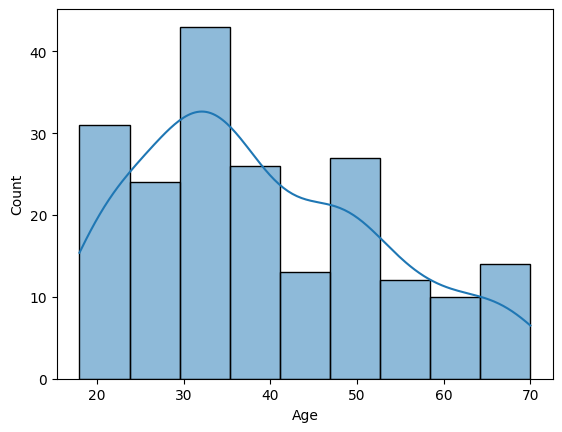

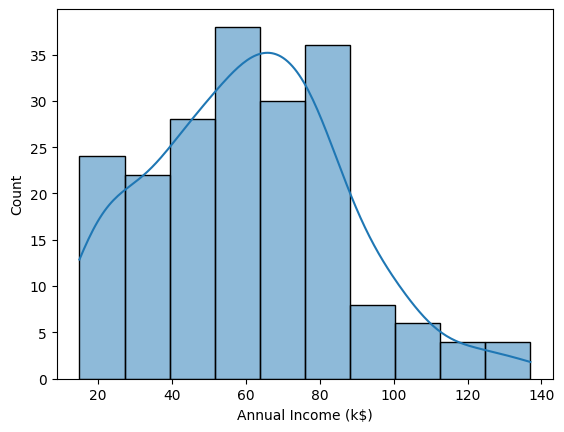

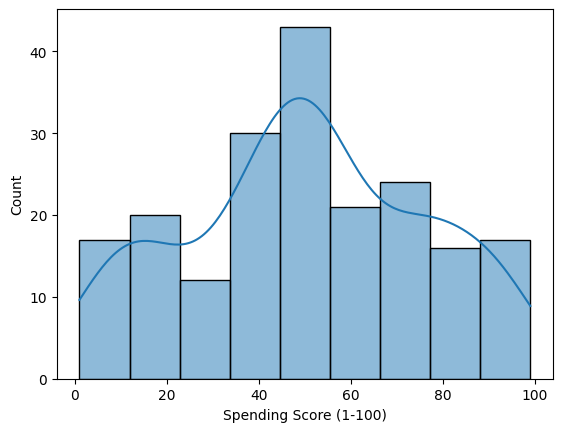

In [4]:
sns.histplot(df['Age'], kde=True)
plt.show()

sns.histplot(df['Annual Income (k$)'], kde=True)
plt.show()

sns.histplot(df['Spending Score (1-100)'], kde=True)
plt.show()

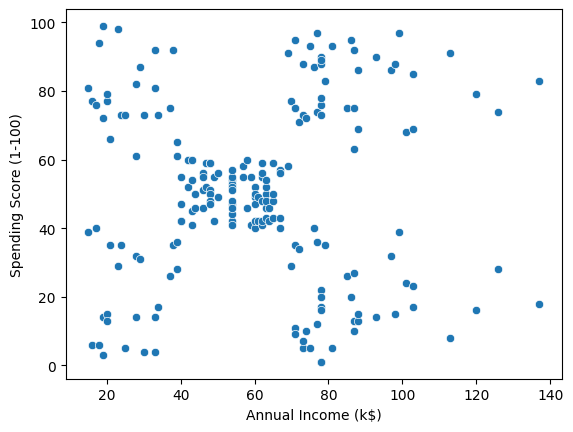

In [5]:
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=df)
plt.show()

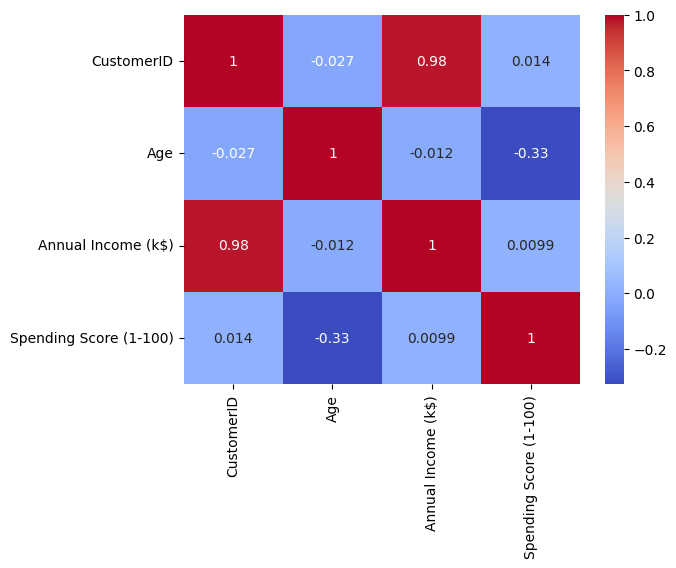

In [6]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [7]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

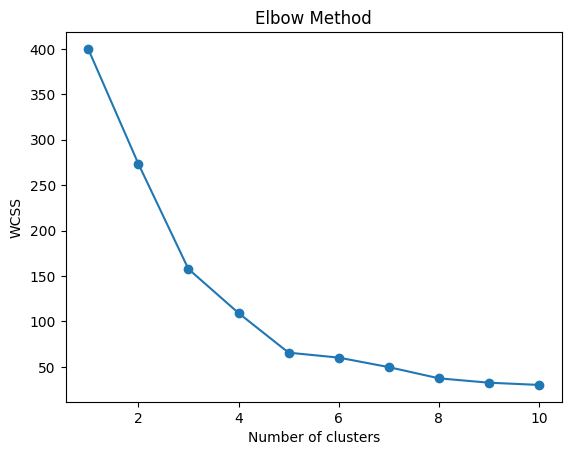

In [8]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [9]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

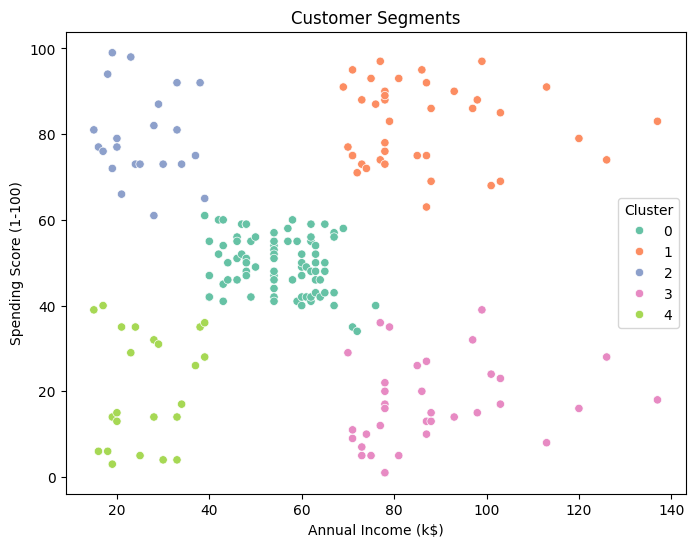

In [10]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set2',
    data=df
)
plt.title('Customer Segments')
plt.show()

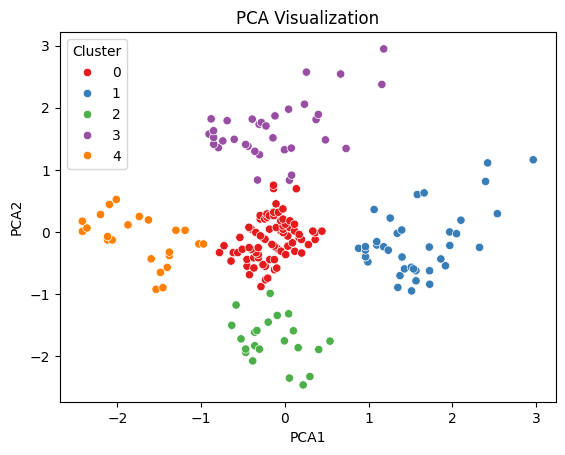

In [11]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:,0]
df['PCA2'] = X_pca[:,1]

sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='Set1')
plt.title('PCA Visualization')
plt.show()

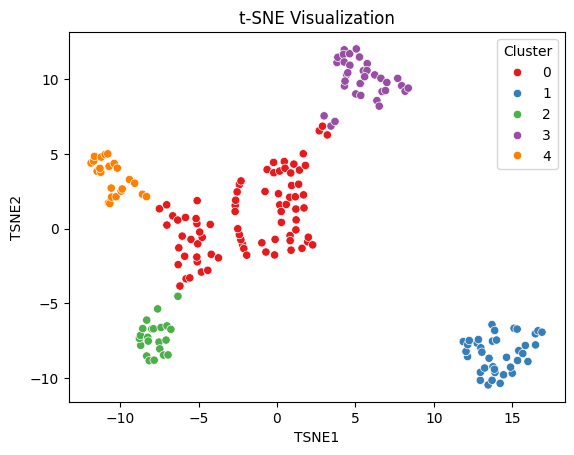

In [12]:
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

df['TSNE1'] = X_tsne[:,0]
df['TSNE2'] = X_tsne[:,1]

sns.scatterplot(x='TSNE1', y='TSNE2', hue='Cluster', data=df, palette='Set1')
plt.title('t-SNE Visualization')
plt.show()

In [13]:
cluster_summary = df.groupby('Cluster').mean(numeric_only=True)
print(cluster_summary)

         CustomerID        Age  Annual Income (k$)  Spending Score (1-100)  \
Cluster                                                                      
0         86.320988  42.716049           55.296296               49.518519   
1        162.000000  32.692308           86.538462               82.128205   
2         23.090909  25.272727           25.727273               79.363636   
3        164.371429  41.114286           88.200000               17.114286   
4         23.000000  45.217391           26.304348               20.913043   

             PCA1      PCA2      TSNE1      TSNE2  
Cluster                                            
0       -0.160774 -0.123359  -1.897479   0.766856  
1        1.577616 -0.175306  14.083862  -8.348732  
2       -0.139560 -1.740701  -7.766327  -7.233999  
3       -0.162236  1.654235   5.421674  10.038340  
4       -1.728511 -0.120599 -10.488124   3.447031  


In [14]:
def marketing_strategy(row):
    income = row['Annual Income (k$)']
    spending = row['Spending Score (1-100)']
    
    if income < 40 and spending < 40:
        return "Budget Customers: Discounts, coupons, low-cost bundles"
    
    elif income > 70 and spending > 70:
        return "VIP Customers: Loyalty programs, premium services"
    
    elif income > 70 and spending < 40:
        return "Potential Buyers: Targeted ads and awareness campaigns"
    
    elif income < 40 and spending > 70:
        return "Impulsive Buyers: Flash sales and limited-time offers"
    
    else:
        return "Average Customers: Cross-selling and combo deals"

In [15]:
df['Marketing Strategy'] = df.apply(marketing_strategy, axis=1)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,PCA1,PCA2,TSNE1,TSNE2,Marketing Strategy
0,1,Male,19,15,39,4,-1.537109,-0.922207,-10.738735,1.729277,"Budget Customers: Discounts, coupons, low-cost..."
1,2,Male,21,15,81,2,-0.384168,-2.075149,-8.684864,-7.809525,Impulsive Buyers: Flash sales and limited-time...
2,3,Female,20,16,6,4,-2.416002,0.010665,-11.847940,4.402368,"Budget Customers: Discounts, coupons, low-cost..."
3,4,Female,23,16,77,2,-0.466982,-1.938355,-8.769373,-7.339450,Impulsive Buyers: Flash sales and limited-time...
4,5,Female,31,17,40,4,-1.455678,-0.895678,-10.651281,1.688390,Average Customers: Cross-selling and combo deals
